# SED Reconstruction Demo - Deep Image Prior (DIP) Version

This script demonstrates the **new Deep Image Prior (DIP)** reconstruction system for SPHEREx narrow-band photometry using PyTorch. 

## Deep Image Prior Overview

Instead of solving for pixel values directly, we optimize the weights of a **generative neural network (1D U-Net)** to map fixed random noise to the observed spectrum. This architectural prior inherently enforces local smoothness and correlation, eliminating Gibbs phenomena and providing global coherence across all bands.


from spxquery.sed import (
    SEDConfig,
    SEDReconstructor,
    SEDReconstructionResult,
    export_default_sed_config,
)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import torch

# Import SED reconstruction module
from spxquery.sed import (
    SEDConfig,
    SEDReconstructor,
    export_default_sed_config,
)
from spxquery.sed.data_loader import load_all_bands

# Check device availability
device = "mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Configure matplotlib for better plots
plt.rcParams["figure.dpi"] = 100
plt.rcParams["font.size"] = 10

print("DIP-based SED reconstruction module imported successfully!")

Using device: mps
DIP-based SED reconstruction module imported successfully!


## 2. Configure Deep Spectral Prior Reconstruction
We configure the `SEDConfig` to use the PyTorch solver (`solver_type="torch"`) and set optimization parameters.

In [2]:
# Configure for Deep Spectral Prior
config_dip = SEDConfig(
    # solver_type="torch",  # Use PyTorch solver
    device=device,  # Use GPU acceleration if available
    # Global Grid Settings
    wavelength_range=(0.75, 5.0),  # Full spectral range
    global_resolution=3000,  # High-resolution grid
    # Ensemble parameters
    ensemble_size=5,  # Number of ensemble members
    ensemble_random_seed=1027,  # Base seed for reproducible ensembles
    # Optimization Parameters
    epochs=6000,  # Number of iterations (DIP needs more epochs)
    learning_rate=0.001,  # Learning rate for Adam
    learning_rate_min_factor=0.05,  # Minimum LR factor for scheduling
    learning_rate_scheduler_type="cosine_warmup",  # Learning rate scheduler type
    learning_rate_warmup_epochs=300,  # Warmup epochs for scheduler
    # CWT Scales for Regularization
    regularization_weight=0.01,  # Weight for CWT sparsity loss
    cwt_scales=[1.0, 2.0, 3.0],  # Scales for Mexican Hat wavelets
    # Settings for EMA smoothing
    use_ema=True,
    ema_decay=0.99,
    ema_start_epoch=2000,
    # Neural Network Architecture
    dip_filters=32,  # Base filters in U-Net
    dip_depth=3,  # Depth of U-Net
    dip_noise_std=0.1,  # Input noise standard deviation
    dip_noise_jitter_initial_ratio=0.3,  # Initial jitter ratio
    dip_noise_jitter_min_ratio=None,  # No minimum jitter
    # Pre-processing
    sigma_threshold=3.0,
    enable_sigma_clip=True,
)

print("DIP Configuration:")
# print(f"  Solver: {config_dip.solver_type}")
print(f"  Resolution: {config_dip.global_resolution} pixels")
print(f"  Device: {config_dip.device}")
print(f"  Epochs: {config_dip.epochs}")

DIP Configuration:
  Resolution: 3000 pixels
  Device: mps
  Epochs: 6000


## 3. Data Preparation
We'll use one of the demo lightcurve CSV files. We load both the raw data (for context) and the cleaned data (actually used in fitting).

In [3]:
# Select input CSV file
input_csv = Path("demo_data/spec_refine/39633446351407006_lc.csv")

# Define output directory for DIP results
output_dir = Path("demo_data/spec_refine/dip_output")
output_dir.mkdir(parents=True, exist_ok=True)

print(f"Input CSV: {input_csv}")
print(f"Output directory: {output_dir}")

# 1. Load raw lightcurve data (for reference)
lc_data_raw = pd.read_csv(input_csv)
print(f"Total raw measurements: {len(lc_data_raw)}")

# 2. Load and CLEAN data using the same pipeline logic as the reconstructor
# This applies flags, SNR cuts, and sigma clipping based on config_dip
band_data_dict, metadata = load_all_bands(input_csv, config_dip)

# Count cleaned measurements
total_cleaned = sum(len(bd.flux) for bd in band_data_dict.values())
print(f"Total cleaned measurements (used for fitting): {total_cleaned}")
print(f"Rejected: {len(lc_data_raw) - total_cleaned} measurements")

print("Measurements per band (cleaned):")
for band, bd in band_data_dict.items():
    print(f"  {band}: {len(bd.flux)}")

Input CSV: demo_data/spec_refine/39633446351407006_lc.csv
Output directory: demo_data/spec_refine/dip_output
Total raw measurements: 8171
Total cleaned measurements (used for fitting): 7484
Rejected: 687 measurements
Measurements per band (cleaned):
  D1: 1058
  D2: 1529
  D3: 1235
  D4: 1028
  D5: 1455
  D6: 1179


## 4. Run Global Reconstruction
This step builds the global dataset and runs the PyTorch optimization loop.

In [4]:
reconstructor_dip = SEDReconstructor(config_dip)

# Run reconstruction
# This returns per-band results extracted from the global spectrum
result_dip = reconstructor_dip.reconstruct_from_csv(input_csv)

print("\nDIP reconstruction complete!")

Optimizing Spectrum: 100%|██████████| 6000/6000 [01:06<00:00, 89.98it/s, Loss=1.6829e+01, Data=1.6011e+01, Reg=8.1750e-01, LR=5.07e-05] 
  -> Significant residual oscillation detected (p < 0.05)
  -> Residuals deviate from Gaussian distribution
Optimizing Spectrum: 100%|██████████| 6000/6000 [01:07<00:00, 88.83it/s, Loss=1.6149e+01, Data=1.5311e+01, Reg=8.3768e-01, LR=5.07e-05]
  -> Significant residual oscillation detected (p < 0.05)
  -> Residuals deviate from Gaussian distribution
Optimizing Spectrum: 100%|██████████| 6000/6000 [01:07<00:00, 88.75it/s, Loss=1.5548e+01, Data=1.4813e+01, Reg=7.3525e-01, LR=5.07e-05]
  -> Significant residual oscillation detected (p < 0.05)
  -> Residuals deviate from Gaussian distribution
Optimizing Spectrum: 100%|██████████| 6000/6000 [01:07<00:00, 89.50it/s, Loss=1.5640e+01, Data=1.4853e+01, Reg=7.8770e-01, LR=5.07e-05]
  -> Significant residual oscillation detected (p < 0.05)
  -> Residuals deviate from Gaussian distribution
Optimizing Spectrum: 10


DIP reconstruction complete!


# 5. Fitting Quality Assessment Using Refactored Plotting Functions

This section demonstrates the fitting quality of the DIP reconstruction using the refactored modular plotting functions from `src/spxquery/sed/plots.py`.

Using refactored plotting functions to assess DIP reconstruction quality...
Ensemble reconstruction detected - using mean flux and confidence bands


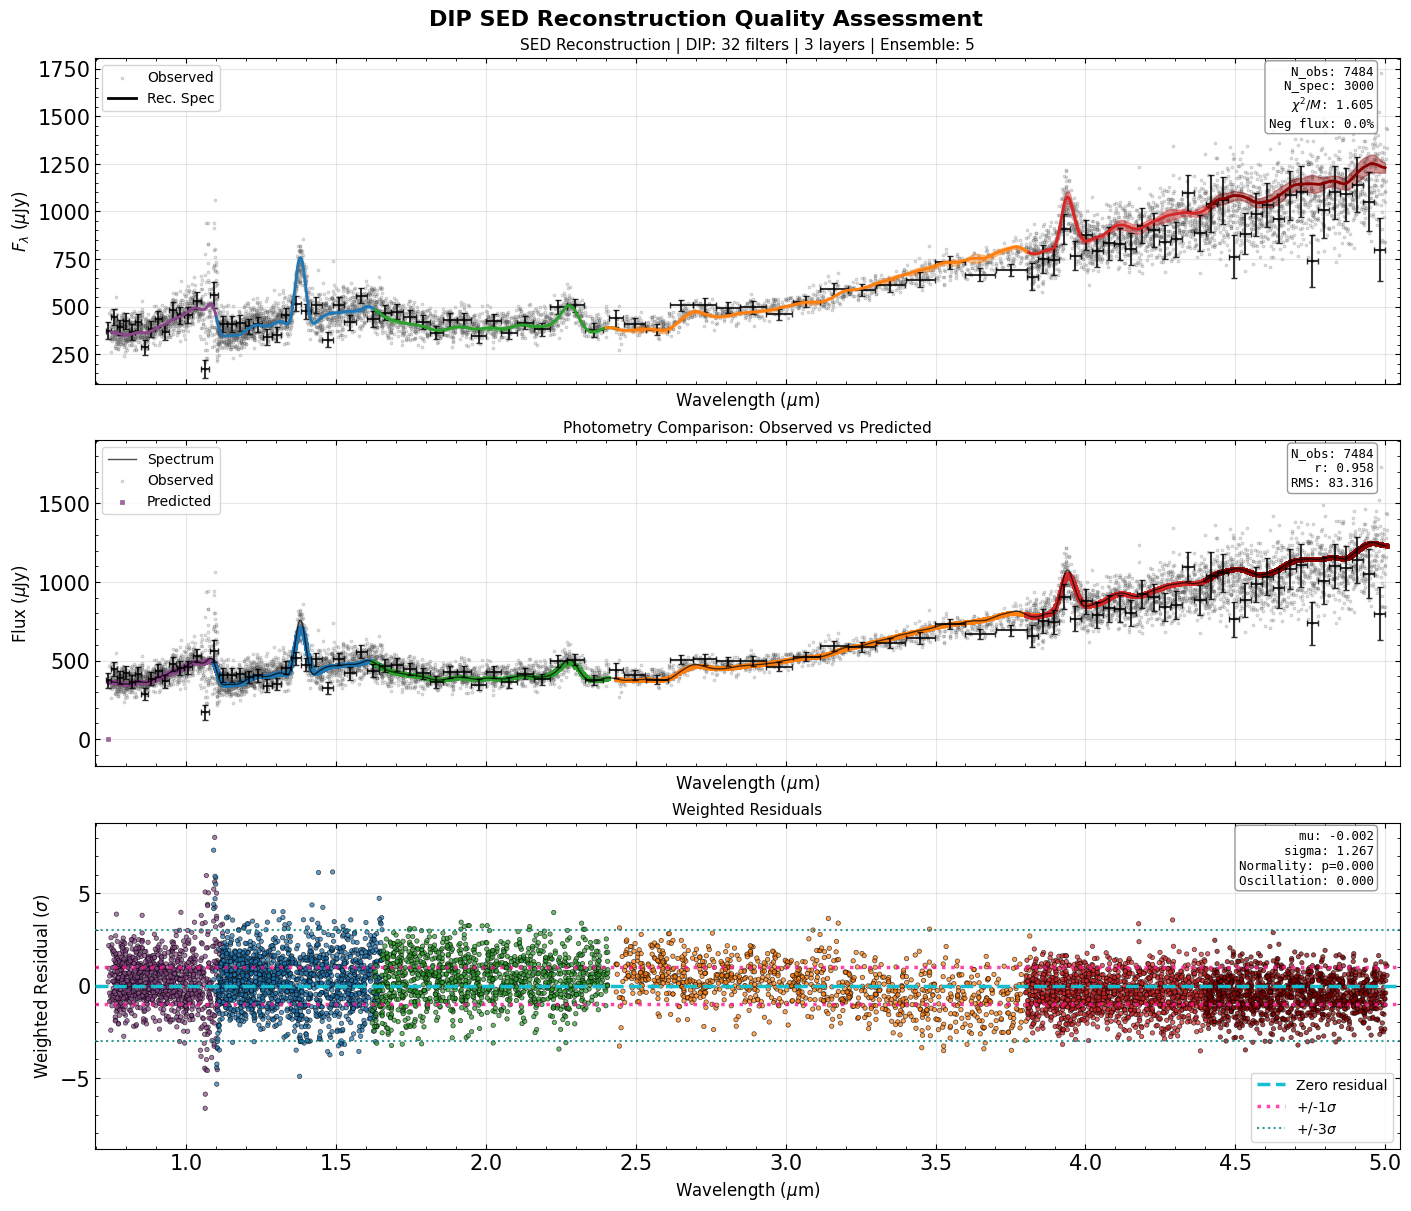


Reconstruction Summary:
  Wavelength range: 0.750 - 5.000 $\mu$m
  Spectral resolution: 3000 pixels
  Total observations used: 7484
  Result type: Ensemble
  Ensemble size: 5
  Mean uncertainty: 12.78 $\mu$Jy


In [5]:
import importlib

# Import the refactored plotting functions
# Reload the plotting functions to ensure latest changes are used
import spxquery.sed.plots

importlib.reload(spxquery.sed.plots)

from spxquery.sed.plots import (
    plot_reconstructed_spectrum_with_data,
    plot_weighted_residuals,
    plot_photometry_comparison,
)

print("Using refactored plotting functions to assess DIP reconstruction quality...")

# Handle both single and ensemble results
if hasattr(result_dip, "mean_flux"):
    # Ensemble result detected
    print("Ensemble reconstruction detected - using mean flux and confidence bands")
    wavelength = result_dip.wavelength
    flux = result_dip.mean_flux
    ensemble_std = result_dip.std_flux
    is_ensemble = True
    validation_metrics = result_dip.validation_metrics
else:
    # Single result detected
    print("Single reconstruction detected")
    wavelength = result_dip.wavelength
    flux = result_dip.flux
    ensemble_std = None
    is_ensemble = False
    validation_metrics = result_dip.validation_metrics

# Create a comprehensive dashboard figure
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex="all")
fig.suptitle("DIP SED Reconstruction Quality Assessment", fontsize=16, fontweight="bold")

# Upper plot: Reconstructed spectrum with data
ax1 = axes[0]
plot_reconstructed_spectrum_with_data(
    ax1, wavelength, flux, band_data_dict, config_dip, ensemble_std, validation_metrics
)
# ax1.set_yscale("log")

ax2 = axes[1]
plot_photometry_comparison(ax2, band_data_dict, config_dip, flux, wavelength=wavelength)  # Use new signature


# Lower plot: Weighted residuals
ax3 = axes[2]
plot_weighted_residuals(ax3, wavelength, flux, band_data_dict, validation_metrics)

# Adjust layout
plt.show()

# Print summary statistics
print(f"\nReconstruction Summary:")
print(f"  Wavelength range: {wavelength[0]:.3f} - {wavelength[-1]:.3f} $\\mu$m")
print(f"  Spectral resolution: {len(wavelength)} pixels")
print(f"  Total observations used: {sum(len(bd.flux) for bd in band_data_dict.values())}")
print(f"  Result type: {'Ensemble' if is_ensemble else 'Single'}")
if is_ensemble:
    print(f"  Ensemble size: {result_dip.ensemble_size}")
    print(f"  Mean uncertainty: {np.mean(ensemble_std):.2f} $\\mu$Jy")
else:
    print(f"  Solver status: {result_dip.solver_status}")
    print(f"  Solver time: {result_dip.solver_time:.2f} seconds")

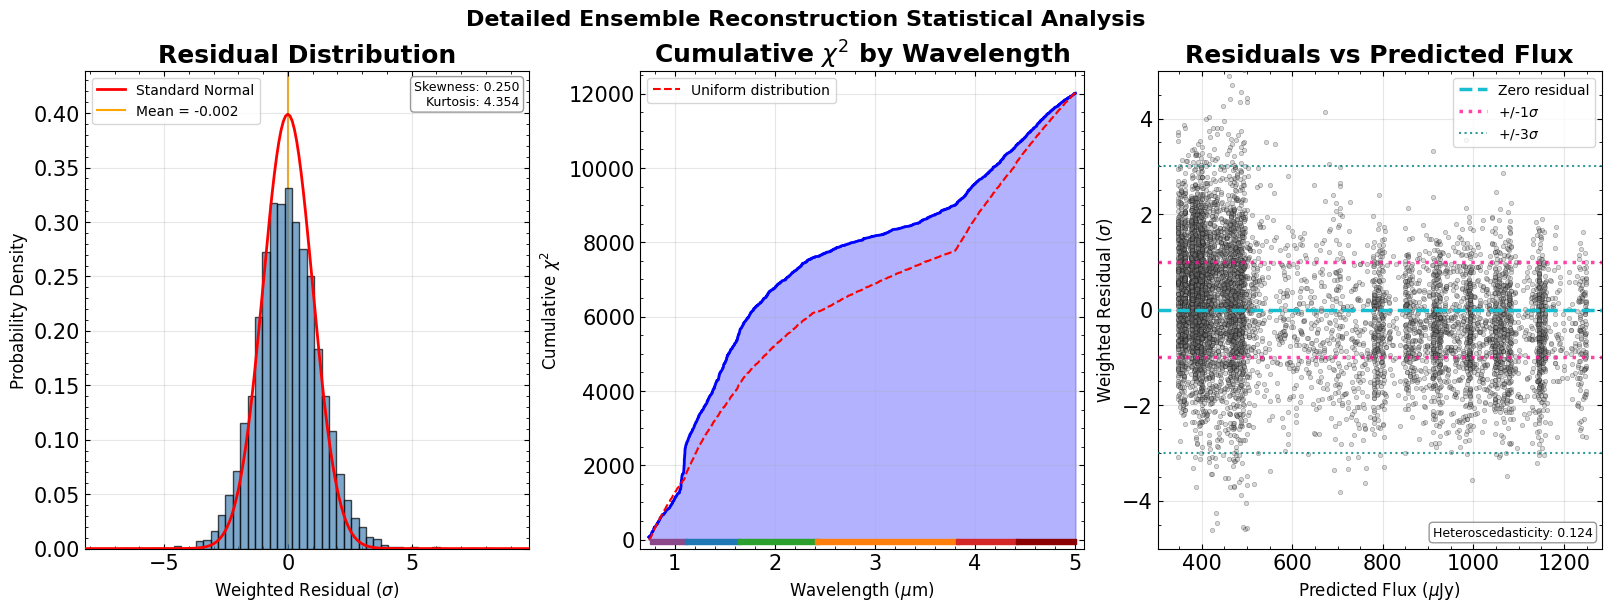

In [6]:
# Detailed Statistical Analysis and Band-by-Band Assessment

importlib.reload(spxquery.sed.plots)

from spxquery.sed.plots import (
    plot_residual_distribution,
    plot_cumulative_chi_squared,
    plot_residuals_vs_flux,
)

# Create multi-panel statistical analysis
fig = plt.figure(figsize=(16, 6))

# 1. Residual distribution
ax1 = plt.subplot(1, 3, 1)
# weighted_residuals = (observed_flux - predicted_flux) / flux_errors
plot_residual_distribution(ax1, validation_metrics.weighted_residuals)
ax1.set_title("Residual Distribution", fontweight="bold")

# 2. Cumulative chi-squared
ax2 = plt.subplot(1, 3, 2)
plot_cumulative_chi_squared(ax2, band_data_dict, validation_metrics.weighted_residuals)
ax2.set_title("Cumulative $\\chi^2$ by Wavelength", fontweight="bold")

# 3. Residuals vs flux
ax3 = plt.subplot(1, 3, 3)
plot_residuals_vs_flux(ax3, band_data_dict, config_dip, flux)  # Use new signature
ax3.set_title("Residuals vs Predicted Flux", fontweight="bold")

plt.suptitle(
    f"Detailed {'Ensemble' if is_ensemble else 'DIP'} Reconstruction Statistical Analysis",
    fontsize=16,
    fontweight="bold",
)
plt.show()


# 6. Save Reconstruction Results
Finally, we save the reconstruction results, including SEDs, metrics, and plots, to the specified output directory.

In [7]:
importlib.reload(spxquery.sed.io)         # Orchestration functions
from spxquery.sed.io import sed_save_all, sed_load_all

sed_save_all("/Users/wenke/data/20250805SPHEREX/spxquery/example/demo_data/spec_refine/output", result_dip)

/Users/wenke/data/20250805SPHEREX/spxquery/src/spxquery/sed/plots.py:1157: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.savefig(output_path, dpi=dpi, bbox_inches="tight")


In [8]:
temp = sed_load_all("/Users/wenke/data/20250805SPHEREX/spxquery/example/demo_data/spec_refine/output")